In [1]:
pip install tensorflow


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.initializers import RandomNormal, GlorotUniform, HeNormal


In [3]:
np.random.seed(42)
tf.random.set_seed(42)

# Simple input-output mapping
X = np.random.randn(1000, 20)
y = np.sum(X, axis=1, keepdims=True)


In [4]:
def create_deep_model(init_std=0.01, activation='tanh'):
    model = Sequential()
    
    for i in range(10):
        model.add(Dense(
            64,
            activation=activation,
            kernel_initializer=RandomNormal(mean=0.0, stddev=init_std)
        ))
    
    model.add(Dense(1))  # Output layer
    return model


In [5]:
vanishing_model = create_deep_model(init_std=0.01, activation='tanh')

vanishing_model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='mse'
)

history_vanishing = vanishing_model.fit(
    X, y,
    epochs=30,
    batch_size=32,
    verbose=0
)


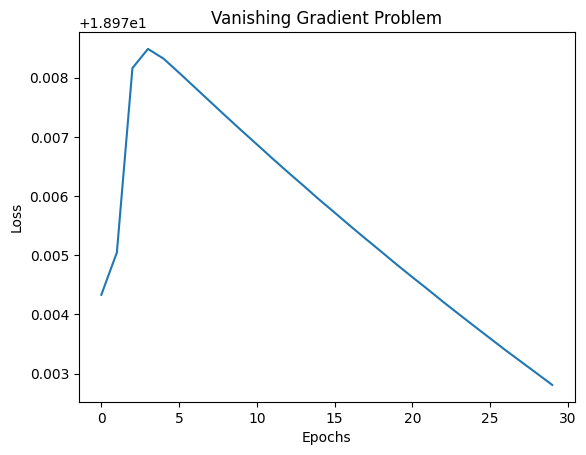

In [6]:
plt.plot(history_vanishing.history['loss'])
plt.title("Vanishing Gradient Problem")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


In [7]:
exploding_model = create_deep_model(init_std=1.0, activation='tanh')

exploding_model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='mse'
)

history_exploding = exploding_model.fit(
    X, y,
    epochs=30,
    batch_size=32,
    verbose=0
)


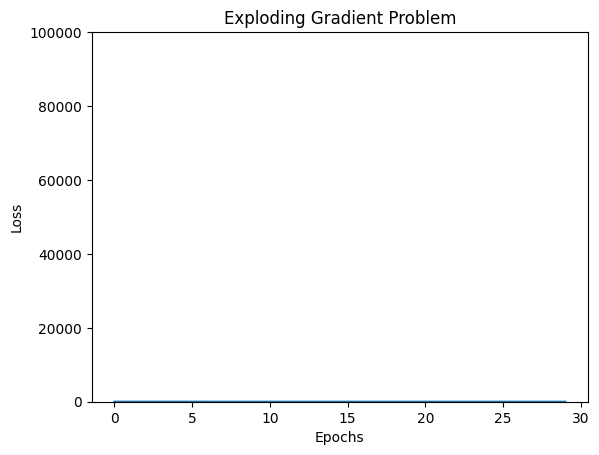

In [8]:
plt.plot(history_exploding.history['loss'])
plt.title("Exploding Gradient Problem")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.ylim(0, 1e5)
plt.show()


In [9]:
symmetry_model = Sequential()

for _ in range(5):
    symmetry_model.add(Dense(
        64,
        activation='relu',
        kernel_initializer='zeros'  # BAD
    ))

symmetry_model.add(Dense(1))


In [10]:
symmetry_model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='mse'
)

history_symmetry = symmetry_model.fit(
    X, y,
    epochs=20,
    batch_size=32,
    verbose=0
)


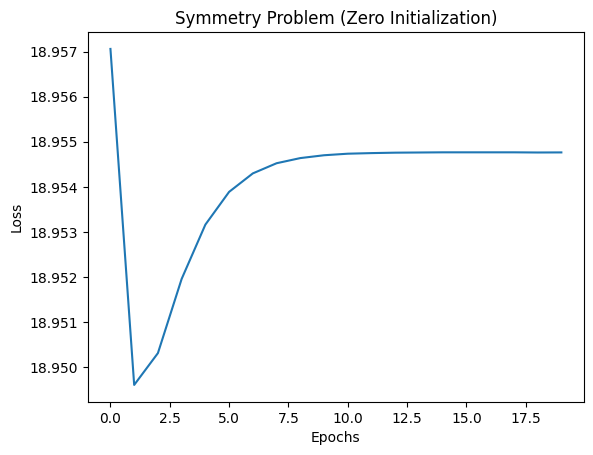

In [11]:
plt.plot(history_symmetry.history['loss'])
plt.title("Symmetry Problem (Zero Initialization)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


Weight Initialization Techniques

In [12]:
xavier_model = Sequential()

for _ in range(10):
    xavier_model.add(Dense(
        64,
        activation='tanh',
        kernel_initializer=GlorotUniform()
    ))

xavier_model.add(Dense(1))


In [13]:
xavier_model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='mse'
)

history_xavier = xavier_model.fit(
    X, y,
    epochs=30,
    batch_size=32,
    verbose=0
)


In [14]:
he_model = Sequential()

for _ in range(10):
    he_model.add(Dense(
        64,
        activation='relu',
        kernel_initializer=HeNormal()
    ))

he_model.add(Dense(1))


In [15]:
he_model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='mse'
)

history_he = he_model.fit(
    X, y,
    epochs=30,
    batch_size=32,
    verbose=0
)


In [16]:
adam_model = Sequential()

for _ in range(10):
    adam_model.add(Dense(
        64,
        activation='relu',
        kernel_initializer=HeNormal()
    ))

adam_model.add(Dense(1))


In [17]:
adam_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

history_adam = adam_model.fit(
    X, y,
    epochs=30,
    batch_size=32,
    verbose=0
)


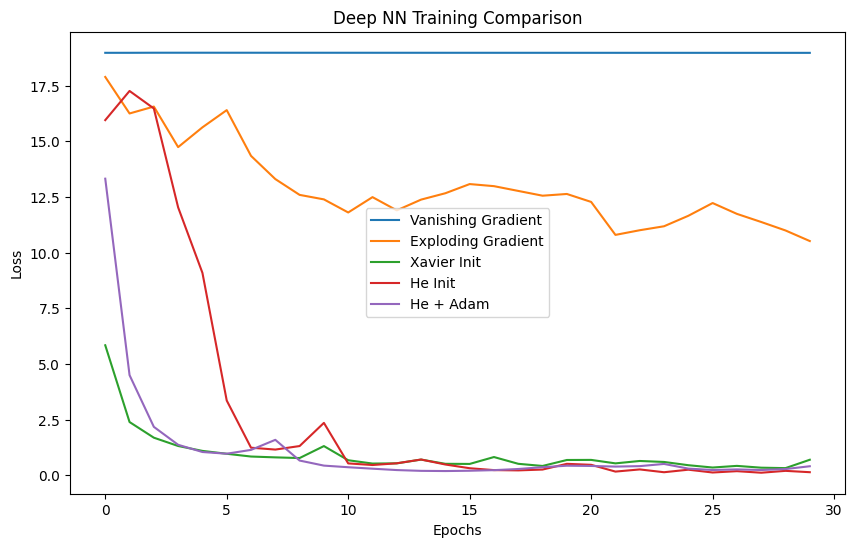

In [18]:
plt.figure(figsize=(10,6))

plt.plot(history_vanishing.history['loss'], label='Vanishing Gradient')
plt.plot(history_exploding.history['loss'], label='Exploding Gradient')
plt.plot(history_xavier.history['loss'], label='Xavier Init')
plt.plot(history_he.history['loss'], label='He Init')
plt.plot(history_adam.history['loss'], label='He + Adam')

plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Deep NN Training Comparison")
plt.show()
